<a href="https://colab.research.google.com/github/AyeshaThapa/Projects/blob/main/Drugs_side_effects_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


Library Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


In [ ]:
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/drugs_side_effects_drugs_com.csv')


In [ ]:
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2931 entries, 0 to 2930
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   drug_name                      2931 non-null   object 
 1   medical_condition              2931 non-null   object 
 2   side_effects                   2807 non-null   object 
 3   generic_name                   2888 non-null   object 
 4   drug_classes                   2849 non-null   object 
 5   brand_names                    1718 non-null   object 
 6   activity                       2931 non-null   object 
 7   rx_otc                         2930 non-null   object 
 8   pregnancy_category             2702 non-null   object 
 9   csa                            2931 non-null   object 
 10  alcohol                        1377 non-null   object 
 11  related_drugs                  1462 non-null   object 
 12  medical_condition_description  2931 non-null   o

,rating,no_of_reviews
count,1586.000000,1586.000000
mean,6.812926,75.064943
std,2.313044,184.900847
min,0.000000,1.000000
25%,5.600000,2.000000
50%,7.000000,12.000000
75%,8.500000,58.000000
max,10.000000,2934.000000


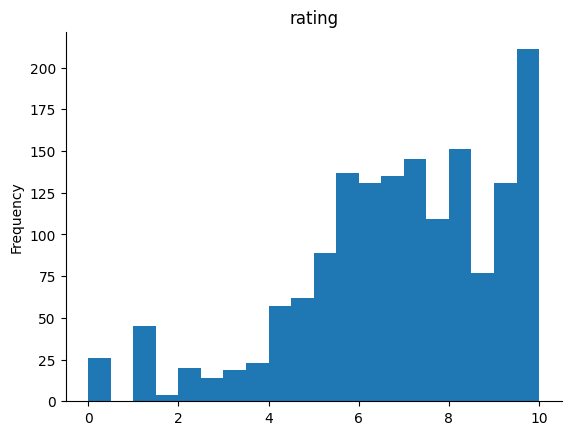

In [ ]:
from matplotlib import pyplot as plt
df['rating'].plot(kind='hist', bins=20, title='rating')
plt.gca().spines[['top', 'right',]].set_visible(False)

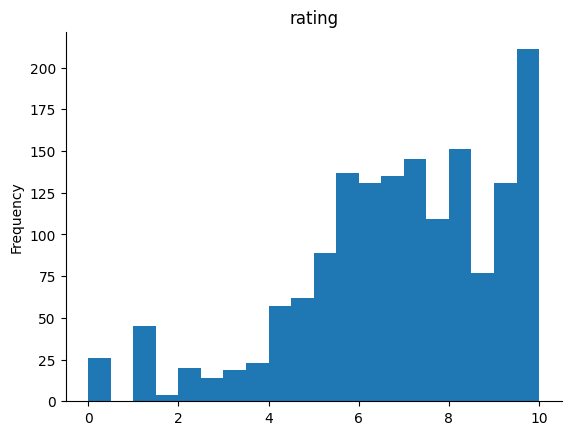

In [ ]:
from matplotlib import pyplot as plt
df['rating'].plot(kind='hist', bins=20, title='rating')
plt.gca().spines[['top', 'right',]].set_visible(False)

Handling missing values

In [ ]:
fill_cols = [
    'side_effects','related_drugs','generic_name',
    'drug_classes','rx_otc','pregnancy_category'
]

for col in fill_cols:
    df[col] = df[col].fillna('Unknown')

df['rating'] = pd.to_numeric(df['rating'], errors='coerce').fillna(0)
df['no_of_reviews'] = pd.to_numeric(df['no_of_reviews'], errors='coerce').fillna(0)

df['activity'] = (
    df['activity'].astype(str)
    .str.replace('%','', regex=False)
    .str.strip()
)
df['activity'] = pd.to_numeric(df['activity'], errors='coerce') / 100


In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['rating'], bins=10, kde=True)
plt.title("Distribution of Drug Ratings")
plt.show()


In [ ]:
df['medical_condition'].value_counts().head(10).plot(kind='bar')
plt.title("Top Medical Conditions")
plt.show()


In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_side_effects"] = df["side_effects"].astype(str).apply(clean_text)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=500
)

X_text = tfidf.fit_transform(df["clean_side_effects"])


In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()
df['sentiment_score'] = df['clean_side_effects'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)


In [ ]:
sns.histplot(df['sentiment_score'], bins=30)
plt.title("Sentiment Score Distribution")
plt.show()


In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(
    n_components=6,
    random_state=42
)

lda_topics = lda.fit_transform(X_text)
df['dominant_topic'] = lda_topics.argmax(axis=1)


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)
df['cluster'] = kmeans.fit_predict(X_text)


In [ ]:
df['cluster'].value_counts().sort_index().plot(kind='bar')
plt.title("Cluster Distribution of Drugs")
plt.show()


In [ ]:
numeric_df = df[['rating','no_of_reviews','activity','sentiment_score']]

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

top_conditions = df['medical_condition'].value_counts().head(10).index
filtered_df = df[df['medical_condition'].isin(top_conditions)]

X = tfidf.transform(filtered_df['clean_side_effects'])
y = filtered_df['medical_condition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)


In [ ]:
print(classification_report(y_test, y_pred))


In [ ]:
# Length-based features
df['side_effect_word_count'] = df['clean_side_effects'].apply(
    lambda x: len(x.split())
)

df['side_effect_char_count'] = df['clean_side_effects'].apply(len)

# Severity proxy using sentiment
df['severity_score'] = df['sentiment_score'].apply(
    lambda x: 'High' if x < -0.4 else ('Medium' if x < -0.1 else 'Low')
)

df[['side_effect_word_count','side_effect_char_count','severity_score']].head()


In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='side_effect_word_count',
    y='rating',
    hue='severity_score',
    data=df
)
plt.title("Side Effect Length vs Drug Rating")
plt.show()


In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(
    x='severity_score',
    hue='medical_condition',
    data=df[df['medical_condition'].isin(top_conditions)]
)
plt.title("Severity Distribution by Medical Condition")
plt.xticks(rotation=45)
plt.show()


In [ ]:
cluster_rating = df.groupby('cluster')['rating'].mean()

cluster_rating.plot(kind='bar')
plt.title("Average Rating per Cluster")
plt.ylabel("Average Rating")
plt.show()


In [ ]:
import plotly.express as px

fig = px.histogram(
    df,
    x='rating',
    nbins=10,
    title="Interactive Distribution of Drug Ratings",
    color='severity_score'
)
fig.show()


In [ ]:
fig = px.scatter(
    df,
    x='side_effect_word_count',
    y='sentiment_score',
    color='cluster',
    hover_data=['drug_name','medical_condition'],
    title="Clusters Based on Side Effects & Sentiment"
)
fig.show()


In [ ]:
severe_drugs = df[df['severity_score'] == 'High'][
    ['drug_name','medical_condition','rating','sentiment_score']
].sort_values('sentiment_score')

severe_drugs.head(20)


In [ ]:
cluster_summary = df.groupby('cluster').agg({
    'rating':'mean',
    'no_of_reviews':'sum',
    'side_effect_word_count':'mean',
    'sentiment_score':'mean'
}).reset_index()

cluster_summary
